# Adult Parameter Sensitivity

One-at-a-time sensitivity checks for DataFrameSampler on capped Adult Census Income. The grids vary NCA dimension, NCA fit row fraction, transport scale, and NCA iterations.

In [1]:
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except NameError:
    pass

from pathlib import Path
import sys

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.datasets import DATASET_CONFIGS
from experiments.parameter_sensitivity import (
    display_line_search_progress,
    plot_parameter_sensitivity,
    plot_repeated_line_search_summary,
    run_adult_parameter_sensitivity,
    run_repeated_iterative_parameter_line_search,
)
from experiments.workflow import (
    experiment_paths,
    load_dataset,
    sampler_config_with_random_state,
    working_dataframe,
)



In [2]:
CONFIG = DATASET_CONFIGS["adult"]
PATHS = experiment_paths(CONFIG)
dataframe = load_dataset(CONFIG)
work = working_dataframe(dataframe, CONFIG)
work.head()

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,18,Private,HS-grad,9,Never-married,Other-service,Not-in-family,White,Male,0,0,20,United-States,<=50K
1,17,Private,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
2,25,Local-gov,HS-grad,9,Never-married,Handlers-cleaners,Other-relative,Black,Male,0,0,40,United-States,<=50K
3,20,Private,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,30,United-States,<=50K
4,47,Private,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,Amer-Indian-Eskimo,Male,0,0,56,Puerto-Rico,<=50K


In [3]:
sampler_config = sampler_config_with_random_state(CONFIG.sampler_config, CONFIG.random_state)
sampler_config.update(
    {
        "decoder_kwargs": {"n_estimators": 100, "n_jobs": -1},
        "nca_kwargs": {"max_iter": 50},
    }
)

n_components_grid = list(range(1, 11))
nca_fit_sample_size_grid = [0.1, 0.25, 0.5, 0.75, 1.0]
lambda_grid = [round(value, 3) for value in np.linspace(0.1, 2.0, 10)]
n_iterations_grid = [1, 2, 3, 4, 5]

In [ ]:
report = run_adult_parameter_sensitivity(
    CONFIG,
    work,
    results_dir=PATHS.results_dir,
    sampler_config=sampler_config,
    max_train_rows=250,
    n_samples=250,
    n_components_grid=n_components_grid,
    nca_fit_sample_size_grid=nca_fit_sample_size_grid,
    lambda_grid=lambda_grid,
    n_iterations_grid=n_iterations_grid,
)
report

In [ ]:
quality_columns = [
    "parameter",
    "value",
    "n_components",
    "nca_fit_sample_size",
    "lambda_",
    "n_iterations",
    "distribution_similarity_score",
    "utility_lift",
    "discrimination_accuracy",
    "nn_distance_ratio",
    "fit_seconds",
    "sample_seconds",
]
report[quality_columns]

In [ ]:
_ = plot_parameter_sensitivity(
    report,
    figures_dir=PATHS.root / "experiments" / "figures",
)

## Iterative rank-based line search

This section starts from the current default sampler configuration and tunes one parameter at a time. For each parameter sweep, every candidate value is ranked separately for each quality measure, then the average rank across measures is used to select the next value. Metrics with a target value are ranked by closeness to the target; metrics where higher is better are ranked directly.

The line search is repeated on three deterministic capped subsets. The plots show light per-seed traces plus mean values with standard-deviation error bars. The line search sweeps `n_iterations` first and skips NCA-only parameters when the current iteration count is zero, because `n_components` and `nca_fit_sample_size` cannot affect a zero-iteration representation.



In [ ]:
line_search_grids = {
    "n_components": n_components_grid,
    "nca_fit_sample_size": nca_fit_sample_size_grid,
    "lambda_": lambda_grid,
    "n_iterations": n_iterations_grid,
}
line_search_repeats = 5
line_search_seeds = [CONFIG.random_state + offset for offset in range(line_search_repeats)]

line_search_history, line_search_report, line_search_summary = run_repeated_iterative_parameter_line_search(
    work,
    dataset_name=CONFIG.dataset_name,
    target_column=CONFIG.target_column,
    base_config=sampler_config,
    parameter_grids=line_search_grids,
    seeds=line_search_seeds,
    max_train_rows=250,
    n_samples=250,
    progress_callback=display_line_search_progress,
)
line_search_history


,step,parameter,selected_value,average_quality_rank,n_seeds,reason,n_iterations,n_components,nca_fit_sample_size,lambda_
0,1,n_iterations,0.0,2.25,5,ok,0,1,0.5,0.25
1,2,n_components,1.0,<NA>,5,skipped because n_iterations=0,0,1,0.5,0.25
2,3,nca_fit_sample_size,0.5,<NA>,5,skipped because n_iterations=0,0,1,0.5,0.25
3,4,lambda_,0.1,3.25,5,ok,0,1,0.5,0.10


,line_search_step,parameter,value,n_seeds,selection_count,mean_average_quality_rank,std_seed_average_quality_rank,mean_distribution_similarity_score,mean_utility_lift,mean_discrimination_accuracy,mean_nn_distance_ratio
0,1,n_iterations,0.000,5,1,2.25,0.547723,0.938317,0.098448,0.529333,0.656002
1,1,n_iterations,3.000,5,0,2.25,0.480885,0.944794,0.085259,0.560000,0.816850
2,1,n_iterations,2.000,5,0,2.50,0.325960,0.941719,0.078297,0.533333,0.819850
3,1,n_iterations,1.000,5,0,3.00,0.586302,0.936593,0.084846,0.569333,0.883350
4,4,lambda_,0.100,5,1,3.25,0.762398,0.946324,0.107793,0.488000,0.574799
5,4,lambda_,0.944,5,0,3.25,1.561249,0.943845,0.079640,0.557333,0.930788
6,4,lambda_,0.311,5,0,4.50,0.790569,0.940425,0.092763,0.520000,0.674991
7,4,lambda_,1.367,5,0,5.00,0.720243,0.935696,0.078732,0.593333,0.975761
8,4,lambda_,0.522,5,0,5.50,1.217066,0.940691,0.069075,0.553333,0.868772
9,4,lambda_,0.733,5,0,5.50,0.802340,0.941617,0.065302,0.561333,0.901216


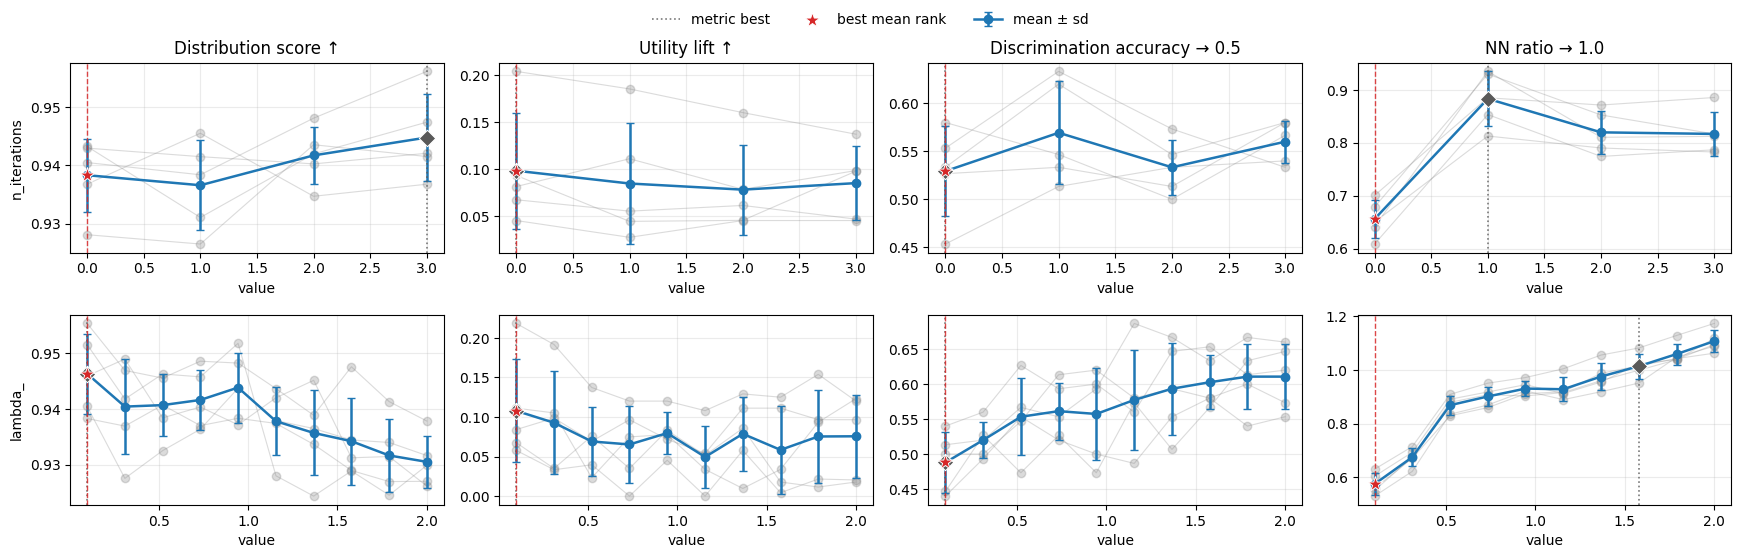

In [ ]:
summary_columns = [
    "line_search_step",
    "parameter",
    "value",
    "n_seeds",
    "selection_count",
    "mean_average_quality_rank",
    "std_seed_average_quality_rank",
    "mean_distribution_similarity_score",
    "mean_utility_lift",
    "mean_discrimination_accuracy",
    "mean_nn_distance_ratio",
]

display(line_search_history)
display(line_search_summary[[column for column in summary_columns if column in line_search_summary.columns]])
_ = plot_repeated_line_search_summary(line_search_report, line_search_summary)

